<a href="https://colab.research.google.com/github/maksimovicd501-wq/Dijabetes/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.Diabetes Dataset - Exploratory Data Analysis

We work with the **Diabetes Dataset for Beginners** (Pima Indians Diabetes dataset) from Kaggle.

The goal of this introductory section is to:
1. Load the data
2. Clean it (handle missing/invalid values)
3. Display basic statistics and several visualizations

This is the preparation step for further work.



### 1.1 Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 1.2 Loading the Data

The dataset is loaded directly from GitHub, so no manual file upload is needed each session.

In [ ]:
url = "https://raw.githubusercontent.com/maksimovicd501-wq/Dijabetes/main/data/diabetes.csv"

df = pd.read_csv(url)
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.shape

(768, 9)

### 1.3 Basic Data Overview

Before cleaning, let's look at column types, check for missing values (NaN), and review basic statistics.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
print("Number of missing (NaN) values per column:")
df.isnull().sum()

Number of missing (NaN) values per column:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


The dataset contains no missing (NaN) values.

In [ ]:
df.describe() #basic statistics

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 1.4 Data Cleaning

Although no NaN values were found in the previous step, the data is not
fully clean. Several columns contain zeros that are biologically impossible
— a value of 0 cannot occur for Glucose, BloodPressure, SkinThickness,
Insulin, or BMI in a living person. These zeros represent missing
measurements that were encoded as 0 instead of NaN.

(The Pregnancies column can legitimately be 0 — it simply means the person
has never been pregnant — so we leave those zeros untouched.)

In [ ]:
cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Number of zeros per column (potentially missing data):")
for col in cols_with_invalid_zeros:
    n_zeros = (df[col] == 0).sum()
    print(f"  {col:25s}: {n_zeros} zeros out of {len(df)} ({n_zeros/len(df)*100:.1f}%)")

Number of zeros per column (potentially missing data):
  Glucose                  : 5 zeros out of 768 (0.7%)
  BloodPressure            : 35 zeros out of 768 (4.6%)
  SkinThickness            : 227 zeros out of 768 (29.6%)
  Insulin                  : 374 zeros out of 768 (48.7%)
  BMI                      : 11 zeros out of 768 (1.4%)


In [ ]:
# Replace zeros with NaN so we can properly impute missing values
df_clean = df.copy()
df_clean[cols_with_invalid_zeros] = df_clean[cols_with_invalid_zeros].replace(0, np.nan)

print("Number of NaN values after replacement:")
df_clean.isnull().sum()

Number of NaN values after replacement:


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### Imputing Missing Values

Since Insulin has 48.7% and SkinThickness has 29.6% missing values,
deleting those rows would reduce the dataset by more than half.
Therefore, we impute missing values using the per-class median,
which is more robust to outliers than the mean.

In [ ]:
for col in cols_with_invalid_zeros:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(lambda x: x.fillna(x.median()))

print("Check — number of NaN values after imputation:")
print(df_clean.isnull().sum().sum(), "total NaN values remaining")
df_clean.head()

Check — number of NaN values after imputation:
0 total NaN values remaining


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


### Checking for Duplicates

In [ ]:
n_duplicates = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

Number of duplicate rows: 0


The data is now clean — no duplicate rows were found, and all missing
values have been imputed. The dataset is ready for further analysis.

### 1.5 Basic Statistics After Cleaning

In [ ]:
df_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 1.6 Distribution of the Target Variable (Outcome)

`Outcome` is the target variable: 1 = the person has diabetes, 0 = they do not. It is important to check whether the dataset is balanced (roughly equal number of examples per class) or imbalanced, as this affects the choice of evaluation metrics and models in later steps.

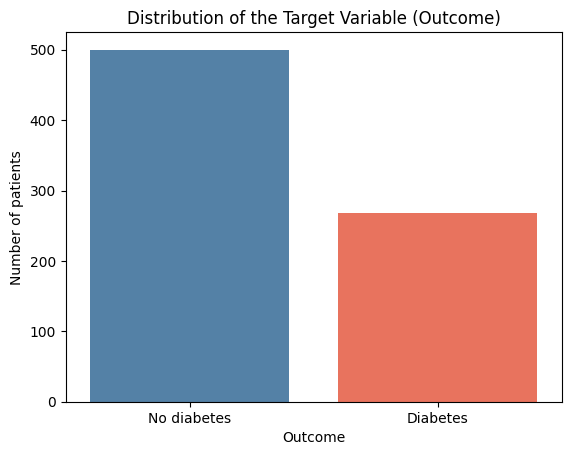

In [ ]:

sns.countplot(data=df_clean, x="Outcome", hue="Outcome", palette=["steelblue", "tomato"], legend=False)
plt.xticks([0, 1], ["No diabetes", "Diabetes"])
plt.title("Distribution of the Target Variable (Outcome)")
plt.ylabel("Number of patients")
plt.show()

The dataset is imbalanced — 500 patients (65%) do not have diabetes
and 268 (35%) do.

### 1.7 Distribution of Key Numerical Features

Let's look at histograms of the most important columns to get a feel for the range and shape of their distributions.

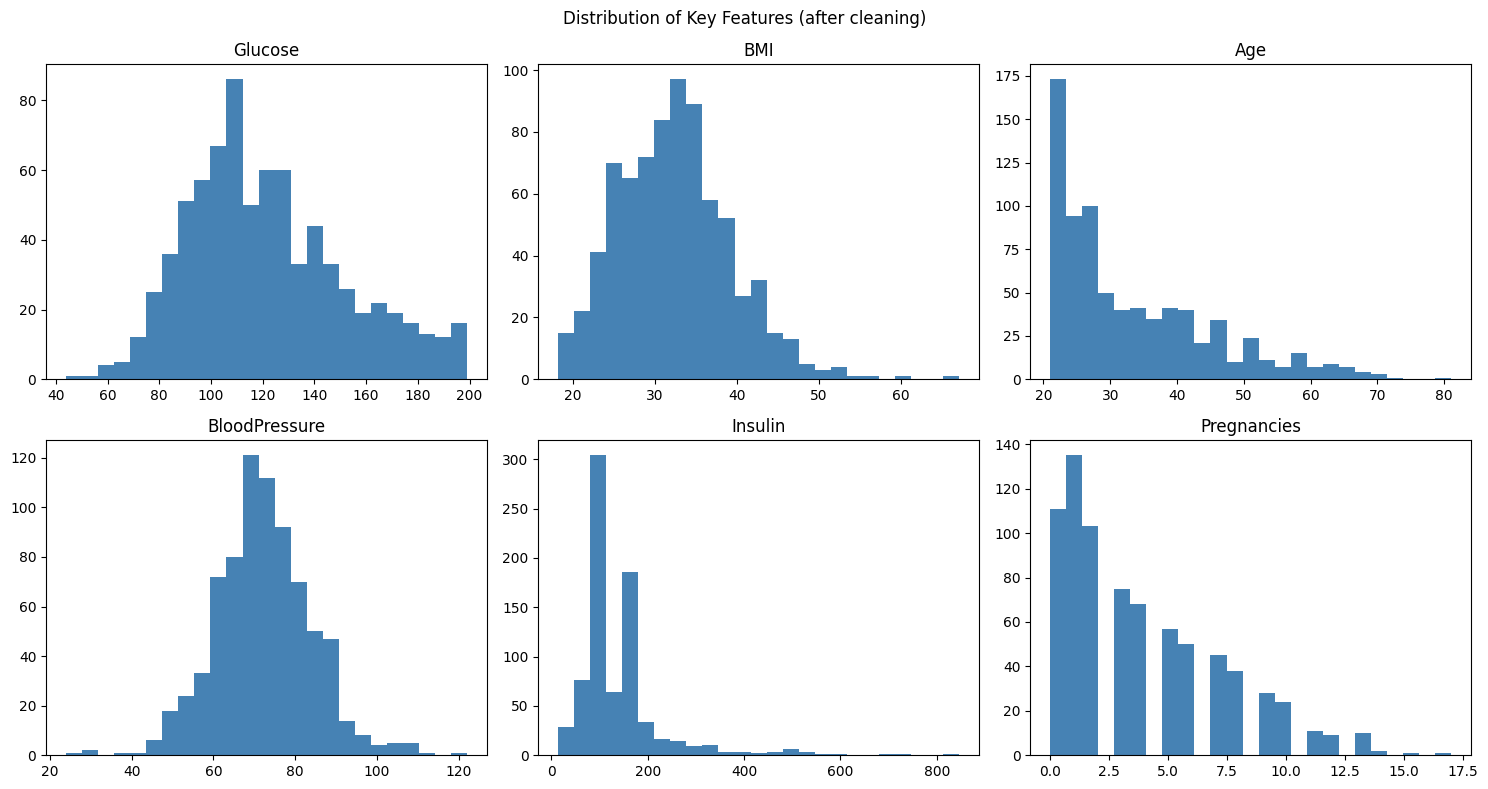

In [ ]:
cols_to_plot = ["Glucose", "BMI", "Age", "BloodPressure", "Insulin", "Pregnancies"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    ax.hist(df_clean[col], bins=25, color="steelblue")
    ax.set_title(col)

plt.suptitle("Distribution of Key Features (after cleaning)")
plt.tight_layout()
plt.show()

Glucose, BloodPressure and BMI approximately follow a normal distribution.
The remaining features (Age, Insulin, Pregnancies) are right-skewed.
This is relevant for Naive Bayes and QDA, which assume Gaussian-distributed
features — the skewed features may slightly violate this assumption.

### 1.8 Feature Comparison Between Classes
We compare feature distributions between diabetic and non-diabetic
patients to identify which features are most useful for classification.

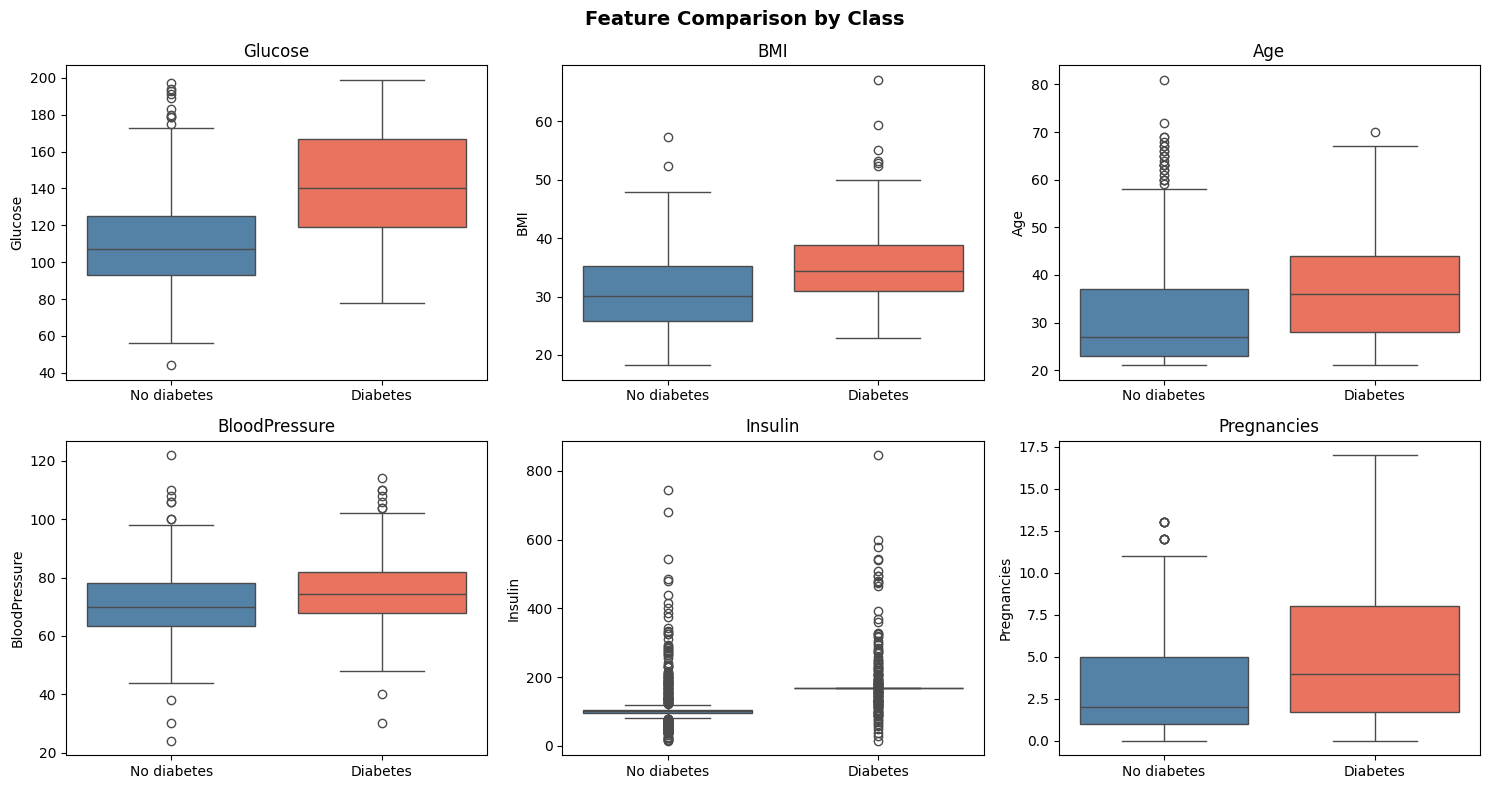

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    sns.boxplot(data=df_clean, x="Outcome", y=col, hue="Outcome", ax=ax, palette=["steelblue", "tomato"], legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No diabetes", "Diabetes"])
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Feature Comparison by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Glucose shows the clearest separation between classes and is the
strongest predictor of diabetes. BMI and Age also show a noticeable
difference between classes. BloodPressure and Pregnancies show
little separation, making them weaker predictors. Insulin has a
large number of outliers, which may affect model performance.

### 1.9 Feature Correlations

The correlation matrix shows the relationships between features.
This is particularly relevant for Naive Bayes, which assumes that
all features are independent — high correlations between features
would indicate a violation of this assumption.

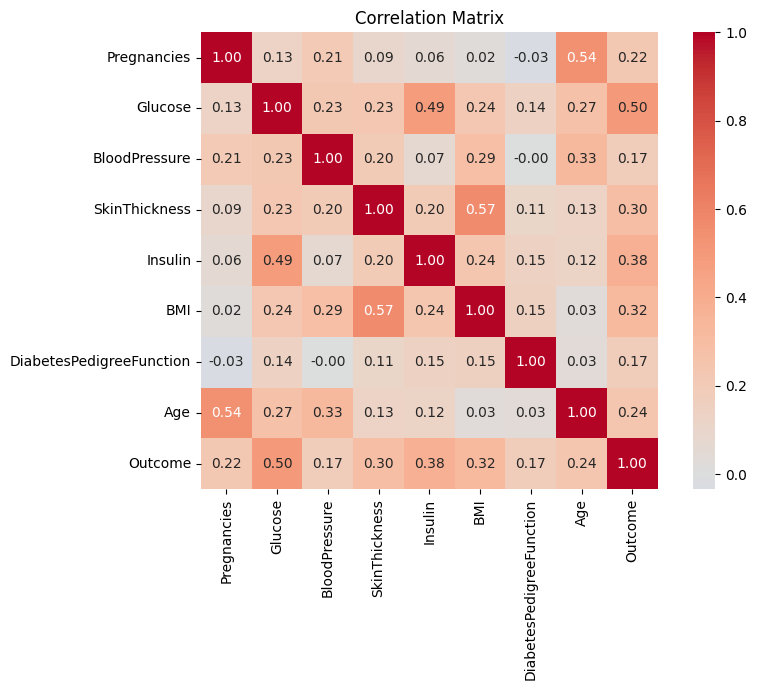

Correlation of each feature with Outcome (sorted):
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


In [ ]:
plt.figure(figsize=(9, 7))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("Correlation of each feature with Outcome (sorted):")
print(corr["Outcome"].drop("Outcome").sort_values(ascending=False))

Glucose has the strongest correlation with Outcome (0.50), followed
by Insulin (0.38) and BMI (0.32). BloodPressure and
DiabetesPedigreeFunction show the weakest correlation with Outcome.

Among the features themselves, the strongest correlations are between
Age and Pregnancies (0.54) and SkinThickness and BMI (0.57). This
suggests that the independence assumption of Naive Bayes is not fully
satisfied, which may slightly affect its performance compared to
QDA and KNN which do not make this assumption.

### 1.10 Summary

- The dataset contains 8 numerical features and a binary target variable `Outcome`.
- The dataset is imbalanced (65% no diabetes, 35% diabetes),
  so accuracy alone will not be sufficient for model evaluation.
- Zeros in columns `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` were identified as missing values and imputed with the per-class median.
- From the boxplots and correlation matrix, `Glucose`, `Insulin` and `BMI` show the strongest association with diabetes — these are the most promising predictors for the classification models.
- The cleaned data (`df_clean`) is now ready for the next steps: standardization, train/test split, and training the classification models (Naive Bayes, QDA, KNN, Weighted KNN).

# 2. Data Preparation
In this section, the cleaned dataset is prepared for classification. The input features and target variable are separated, the data is divided into training and test sets, and feature standardization is applied before training the classification models.

### 2.1 Train-Test Split
The dataset is divided into input features and the target variable (Outcome). A manual train-test split is performed, using 80% of the data for training and 20% for testing. Random shuffling is applied before splitting to ensure a representative distribution of samples in both subsets.

In [ ]:
# Prepare input features and target variable

X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

# Manual train-test split

np.random.seed(42)

indices = np.arange(len(df_clean))
np.random.shuffle(indices)

test_size = int(0.2 * len(df_clean))

test_indices = indices[:test_size]
train_indices = indices[test_size:]

X_train = X.iloc[train_indices]
X_test = X.iloc[test_indices]

y_train = y.iloc[train_indices]
y_test = y.iloc[test_indices]

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (615, 8)
Test set: (153, 8)


### 2.2 Feature Standardization
Since the features are measured on different scales, manual standardization is applied. The mean and standard deviation are computed from the training set and then used to transform both the training and test data. This prevents information leakage from the test set into the training process.

In [ ]:
# Manual standardization using only training data statistics

X_train_np = X_train.values
X_test_np = X_test.values

mean_train = X_train_np.mean(axis=0)
std_train = X_train_np.std(axis=0)

X_train_scaled = (X_train_np - mean_train) / std_train
X_test_scaled = (X_test_np - mean_train) / std_train

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(615, 8)
(153, 8)


# 3. Gaussian Naive Bayes Classification
Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' theorem. Since all features in the dataset are numerical, each feature is modeled using a Gaussian distribution within each class. The classifier estimates class priors, feature means, and feature variances from the training data.

### 3.1 Model Implementation
The Gaussian Naive Bayes classifier is implemented from scratch. For each class, the prior probability, mean, and variance of every feature are estimated from the training data.

In [ ]:
# Estimate class priors, means and variances

def fit_gaussian_naive_bayes(X_train, y_train):

    classes = np.unique(y_train)
    params = {}

    for c in classes:

        X_c = X_train[y_train == c]

        params[c] = {
            "prior": len(X_c) / len(X_train),
            "mean": np.mean(X_c, axis=0),
            "var": np.var(X_c, axis=0) + 1e-9
        }

    return params

In [ ]:
# Compute log Gaussian probability density

def gaussian_log_pdf(X, mean, var):

    return -0.5 * np.sum(
        np.log(2 * np.pi * var)
        + ((X - mean) ** 2) / var,
        axis=1
    )

In [ ]:
# Predict class labels

def predict_gaussian_naive_bayes(X, params):

    log_probs = []

    for c in params:

        log_prior = np.log(params[c]["prior"])

        log_likelihood = gaussian_log_pdf(
            X,
            params[c]["mean"],
            params[c]["var"]
        )

        log_probs.append(log_prior + log_likelihood)

    log_probs = np.vstack(log_probs).T

    classes = np.array(list(params.keys()))

    return classes[np.argmax(log_probs, axis=1)]

### 3.2 Model Training and Prediction
The classifier is trained using the standardized training data. Predictions are then generated for the test set.

In [ ]:
# Train the model

params_nb = fit_gaussian_naive_bayes(
    X_train_scaled,
    y_train.values
)

# Predict test labels

y_pred_nb = predict_gaussian_naive_bayes(
    X_test_scaled,
    params_nb
)
print("Naive Bayes model trained successfully.")
print("Number of predictions:", len(y_pred_nb))
print("First 10 predictions:", y_pred_nb[:10])

Naive Bayes model trained successfully.
Number of predictions: 153
First 10 predictions: [0 0 0 0 1 1 0 0 0 1]


### 3.3 Model Evaluation
The performance of the classifier is evaluated using classification accuracy and a confusion matrix.

In [ ]:
# Build confusion matrix

cm_nb = np.zeros((2, 2), dtype=int)

for true, pred in zip(y_test.values, y_pred_nb):
    cm_nb[int(true), int(pred)] += 1

In [ ]:
print("Confusion Matrix:")
print(cm_nb)

Confusion Matrix:
[[79 19]
 [17 38]]


In [ ]:
accuracy_nb = np.mean(y_test.values == y_pred_nb)

print("Accuracy:", round(accuracy_nb, 4))

Accuracy: 0.7647


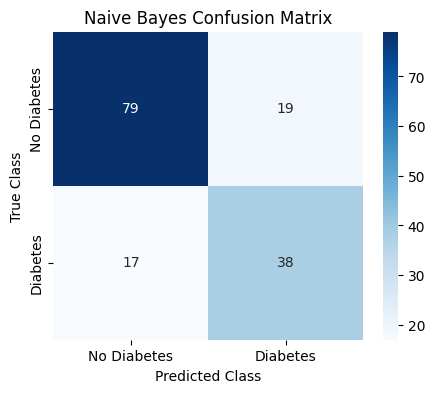

In [ ]:
# Visualize confusion matrix

cm_nb = np.zeros((2, 2), dtype=int)

for true, pred in zip(y_test.values, y_pred_nb):
    cm_nb[int(true), int(pred)] += 1

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

The confusion matrix shows that most samples are classified correctly. However, some diabetic patients are misclassified as non-diabetic and vice versa, indicating an overlap between the two classes.

### 3.4 Feature Distribution Analysis

The distribution of Glucose values differs noticeably between the two classes. Patients with diabetes tend to have higher glucose levels, while non-diabetic patients are concentrated around lower values.

Although the distributions overlap, Glucose provides a strong discriminatory signal and appears to be one of the most informative features for diabetes prediction
(as we saw before in 1.9). This observation is consistent with the correlation analysis and supports the assumptions used by the Gaussian Naive Bayes classifier.

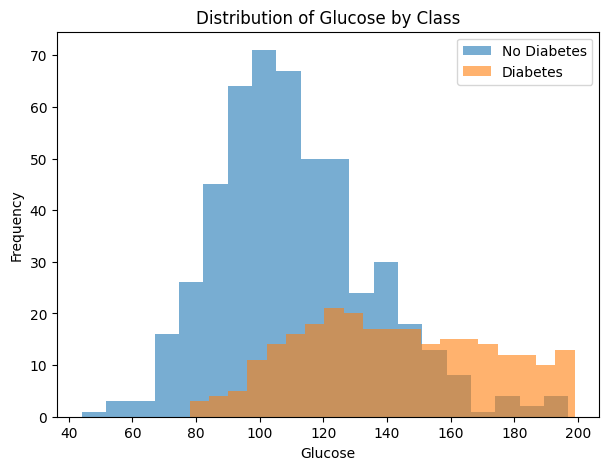

In [ ]:
# Glucose distribution by class

plt.figure(figsize=(7,5))

plt.hist(
    df_clean[df_clean["Outcome"] == 0]["Glucose"],
    bins=20,
    alpha=0.6,
    label="No Diabetes"
)

plt.hist(
    df_clean[df_clean["Outcome"] == 1]["Glucose"],
    bins=20,
    alpha=0.6,
    label="Diabetes"
)

plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.title("Distribution of Glucose by Class")
plt.legend()

plt.show()

The two distributions overlap significantly in the 80–140 glucose
range, which explains the classification errors seen in the confusion
matrix. Non-diabetic patients are concentrated around lower glucose
values (80–120), while diabetic patients tend towards higher values
(120–200), suggesting that higher glucose levels are associated with
a greater likelihood of diabetes.

### 3.5 Decision Boundary Visualization

To visualize the behavior of the classifier, only the two most informative features (Glucose and BMI) are selected. The decision regions illustrate how the Gaussian Naive Bayes classifier separates diabetic and non-diabetic patients in a two-dimensional feature space.

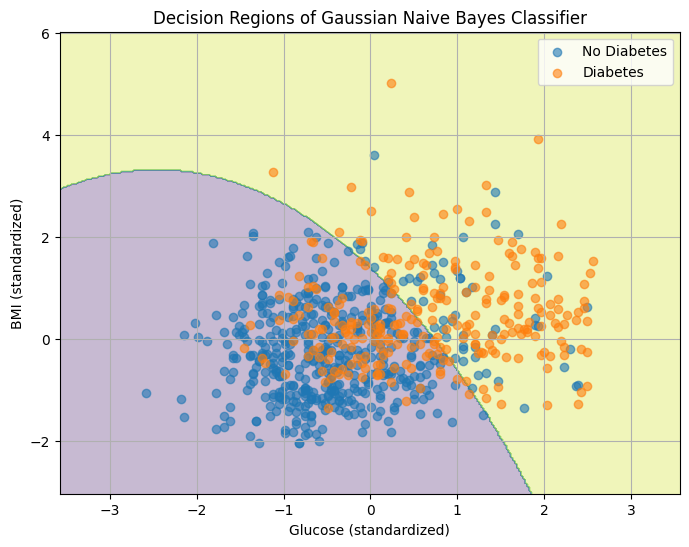

In [ ]:
# Decision regions for Gaussian Naive Bayes using two selected features

feature1 = "Glucose"
feature2 = "BMI"

X_2d = df_clean[[feature1, feature2]].values
y_2d = df_clean["Outcome"].values

# Manual train-test split for 2D data
np.random.seed(42)
indices = np.arange(len(X_2d))
np.random.shuffle(indices)

test_size = int(0.2 * len(X_2d))

test_indices = indices[:test_size]
train_indices = indices[test_size:]

X_train_2d = X_2d[train_indices]
y_train_2d = y_2d[train_indices]

# Manual standardization
mean_2d = X_train_2d.mean(axis=0)
std_2d = X_train_2d.std(axis=0)

X_train_2d_scaled = (X_train_2d - mean_2d) / std_2d
X_2d_scaled = (X_2d - mean_2d) / std_2d

# Train Naive Bayes on two features
params_nb_2d = fit_gaussian_naive_bayes(X_train_2d_scaled, y_train_2d)

# Create grid
x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]

Z = predict_gaussian_naive_bayes(grid_points, params_nb_2d)
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_2d_scaled[y_2d == 0, 0],
    X_2d_scaled[y_2d == 0, 1],
    label="No Diabetes",
    alpha=0.6
)

plt.scatter(
    X_2d_scaled[y_2d == 1, 0],
    X_2d_scaled[y_2d == 1, 1],
    label="Diabetes",
    alpha=0.6
)

plt.xlabel("Glucose (standardized)")
plt.ylabel("BMI (standardized)")
plt.title("Decision Regions of Gaussian Naive Bayes Classifier")
plt.legend()
plt.grid(True)
plt.show()

The decision boundary is nonlinear because Gaussian Naive Bayes models each feature distribution separately for each class. Diabetic patients tend to be more concentrated towards higher glucose values, while non-diabetic patients tend to cluster around lower glucose levels. However, a noticeable overlap remains between the two classes, which explains the classification errors observed in the evaluation results.